In [ ]:
# ================= OPTUNA + CATBOOST TRAINING PIPELINE =================

import os
import numpy as np
import pandas as pd
import optuna

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    f1_score,
    roc_curve,
    auc
)

from catboost import CatBoostClassifier
import joblib

# ---------------- CONFIG ----------------
os.chdir(r"C:\Users\navee\Desktop\Documents\Minor Project\project")

DATA_PATH = "data/final_standardized_dataset(2).csv"

OUT_DIR = os.path.join("outputs", "catboost_optuna")
os.makedirs(OUT_DIR, exist_ok=True)

MODEL_OUT = os.path.join(OUT_DIR, "catboost_best_model.cbm")
PRED_OUT = os.path.join(OUT_DIR, "catboost_test_predictions.csv")

RANDOM_STATE = 42
N_TRIALS = 50          
# ----------------------------------------

# =================  LOAD DATA =================

df = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH, "shape:", df.shape)

def map_category(s):
    if s == 0:
        return 0
    elif s == 1:
        return 1
    else:
        return 2

df["risk_category"] = df["composite_risk_score"].apply(map_category)

exclude = [
    "patient_id",
    "composite_risk_score",
    "composite_risk_category",
    "risk_category"
]

features = [c for c in df.columns if c not in exclude]

for c in features:
    if df[c].dtype == "object":
        df[c] = LabelEncoder().fit_transform(df[c].astype(str))

X = df[features]
y = df["risk_category"]

# =================  FIXED SPLIT  =================

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.17647,
    stratify=y_trainval,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

# =================  OPTUNA OBJECTIVE =================

def objective(trial):

    params = {
        "iterations": trial.suggest_int("iterations", 1000, 3000),
        "depth": trial.suggest_int("depth", 5, 9),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "random_strength": trial.suggest_float("random_strength", 0.5, 3),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0)
    }

    # Optimize class weights
    w1 = trial.suggest_float("w1", 1.0, 2.0)
    w2 = trial.suggest_float("w2", 2.0, 5.0)
    class_weights = [1.0, w1, w2]

    model = CatBoostClassifier(
        loss_function="MultiClass",
        eval_metric="TotalF1",
        random_seed=RANDOM_STATE,
        class_weights=class_weights,
        early_stopping_rounds=100,
        verbose=0,
        **params
    )

    model.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        use_best_model=True
    )

    # Threshold tuning for HIGH-RISK class
    probs = model.predict_proba(X_val)
    t2 = trial.suggest_float("t2", 0.2, 0.6)

    preds = []
    for p in probs:
        if p[2] >= t2:
            preds.append(2)
        elif p[1] >= 0.4:
            preds.append(1)
        else:
            preds.append(0)

    preds = np.array(preds)

    macro_f1 = f1_score(y_val, preds, average="macro")
    return macro_f1

# =================  RUN OPTUNA =================

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=N_TRIALS)

print("\nBEST OPTUNA PARAMETERS:")
for k, v in study.best_trial.params.items():
    print(f"{k}: {v}")

print("Best Validation Macro-F1:", study.best_value)

# =================  FINAL MODEL TRAIN =================

best = study.best_trial.params

best_class_weights = [1.0, best["w1"], best["w2"]]

final_model = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="TotalF1",
    iterations=best["iterations"],
    depth=best["depth"],
    learning_rate=best["learning_rate"],
    l2_leaf_reg=best["l2_leaf_reg"],
    random_strength=best["random_strength"],
    bagging_temperature=best["bagging_temperature"],
    class_weights=best_class_weights,
    random_seed=RANDOM_STATE,
    verbose=200
)

final_model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    use_best_model=True
)

final_model.save_model(MODEL_OUT)

# =================  FINAL TEST EVALUATION =================

t2 = best["t2"]
probs_test = final_model.predict_proba(X_test)

y_pred = []
for p in probs_test:
    if p[2] >= t2:
        y_pred.append(2)
    elif p[1] >= 0.4:
        y_pred.append(1)
    else:
        y_pred.append(0)

print("\nFINAL TEST CLASSIFICATION REPORT")
print(classification_report(y_test, y_pred))

# Save predictions
out_df = X_test.copy()
out_df["y_true"] = y_test.values
out_df["y_pred"] = y_pred

for c in range(3):
    out_df[f"proba_class_{c}"] = probs_test[:, c]

out_df.to_csv(PRED_OUT, index=False)

print("\nOptuna + CatBoost pipeline completed successfully.")

[I 2026-01-23 21:45:42,812] A new study created in memory with name: no-name-8e0e8600-2557-4a81-a0fe-b6489f3d6203


Loaded: data/final_standardized_dataset(2).csv shape: (1200, 25)
Train: (840, 24) Val: (180, 24) Test: (180, 24)


[I 2026-01-23 21:46:13,276] Trial 0 finished with value: 0.9557391667026218 and parameters: {'iterations': 2031, 'depth': 7, 'learning_rate': 0.08154211837992244, 'l2_leaf_reg': 5.896849715874268, 'random_strength': 1.8409364478663697, 'bagging_temperature': 0.10451614382172048, 'w1': 1.249519597866734, 'w2': 4.9765251326276605, 't2': 0.41775195842761625}. Best is trial 0 with value: 0.9557391667026218.
[I 2026-01-23 21:46:31,977] Trial 1 finished with value: 0.9617964437319374 and parameters: {'iterations': 2337, 'depth': 5, 'learning_rate': 0.03247172672973807, 'l2_leaf_reg': 6.100903560989977, 'random_strength': 2.216180570073335, 'bagging_temperature': 0.09144776976267155, 'w1': 1.6978917166125505, 'w2': 4.058859775411658, 't2': 0.5804055350967531}. Best is trial 1 with value: 0.9617964437319374.
[I 2026-01-23 21:46:44,422] Trial 2 finished with value: 0.9356617012844722 and parameters: {'iterations': 2346, 'depth': 5, 'learning_rate': 0.015742226031107198, 'l2_leaf_reg': 2.0703782


BEST OPTUNA PARAMETERS:
iterations: 2472
depth: 7
learning_rate: 0.06747794377479946
l2_leaf_reg: 1.1153117935378447
random_strength: 2.0843802167625545
bagging_temperature: 0.30936211786822443
w1: 1.793223222528584
w2: 4.349573620182648
t2: 0.3115077282829453
Best Validation Macro-F1: 0.9896326346630606
0:	learn: 0.6613946	test: 0.6247325	best: 0.6247325 (0)	total: 32.2ms	remaining: 1m 19s
200:	learn: 1.0000000	test: 0.9706289	best: 0.9726762 (148)	total: 4.88s	remaining: 55.2s
400:	learn: 1.0000000	test: 0.9731343	best: 0.9731343 (226)	total: 9.61s	remaining: 49.6s
600:	learn: 1.0000000	test: 0.9731343	best: 0.9731343 (226)	total: 15s	remaining: 46.6s
800:	learn: 1.0000000	test: 0.9731343	best: 0.9731343 (226)	total: 19.6s	remaining: 41s
1000:	learn: 1.0000000	test: 0.9731343	best: 0.9731343 (226)	total: 24.1s	remaining: 35.4s
1200:	learn: 1.0000000	test: 0.9731343	best: 0.9731343 (226)	total: 28.3s	remaining: 29.9s
1400:	learn: 1.0000000	test: 0.9731343	best: 0.9731343 (226)	total:

In [5]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostClassifier, Pool

# ---------------- CONFIG ----------------
DATA_PATH = "data/final_standardized_dataset(2).csv"
MODEL_PATH = "outputs/catboost_optuna/catboost_best_model.cbm"
OUT_IMAGE = "outputs/catboost_optuna/shap_global_importance.png"
RANDOM_STATE = 42
# --------------------------------------

df = pd.read_csv(DATA_PATH)
df["risk_category"] = df["composite_risk_score"].apply(lambda s: 0 if s == 0 else (1 if s == 1 else 2))

exclude = ["patient_id", "composite_risk_score", "composite_risk_category", "risk_category"]
features = [c for c in df.columns if c not in exclude]

for c in features:
    if df[c].dtype == "object":
        df[c] = LabelEncoder().fit_transform(df[c].astype(str))

X = df[features]
y = df["risk_category"]

_, X_test, _, _ = train_test_split(X, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE)

model = CatBoostClassifier()
model.load_model(MODEL_PATH)

# Use Pool for native efficiency
X_shap_sample = X_test.sample(n=min(100, len(X_test)), random_state=RANDOM_STATE)
shap_pool = Pool(X_shap_sample)

# Use native CatBoost SHAP (much faster, no kernel crash)
# Result shape: (samples, classes, features + 1)
shap_values = model.get_feature_importance(shap_pool, type='ShapValues')

# Extract only feature contributions (exclude the base value in the last column)
# and aggregate: Mean of absolute values across samples AND classes
shap_contributions = shap_values[:, :, :-1]
global_importance = np.mean(np.abs(shap_contributions), axis=(0, 1))

# Create a clean DataFrame for plotting
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': global_importance
}).sort_values(by='Importance', ascending=True)

#  Plot global SHAP importance
plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue', edgecolor='black')
plt.xlabel("Mean |SHAP value| (Average Impact on Model Output)")
plt.title("Global SHAP Feature Importance (Aggregated across Classes)")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(OUT_IMAGE, dpi=300)
plt.close()

print(f" Global SHAP importance saved to: {OUT_IMAGE}")

 Global SHAP importance saved to: outputs/catboost_optuna/shap_global_importance.png


In [ ]:
import pandas as pd
import shap
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostClassifier, Pool

# ---------------- CONFIG ----------------
DATA_PATH = "data/final_standardized_dataset(2).csv"
MODEL_PATH = "outputs/catboost_optuna/catboost_best_model.cbm"
OUT_DIR = "outputs/catboost_optuna"
RANDOM_STATE = 42

if not os.path.exists(OUT_DIR):
    os.makedirs(OUT_DIR)
# --------------------------------------

df = pd.read_csv(DATA_PATH)
df["risk_category"] = df["composite_risk_score"].apply(lambda s: 0 if s == 0 else (1 if s == 1 else 2))

exclude = ["patient_id", "composite_risk_score", "composite_risk_category", "risk_category"]
features = [c for c in df.columns if c not in exclude]

for c in features:
    if df[c].dtype == "object":
        df[c] = LabelEncoder().fit_transform(df[c].astype(str))

X = df[features]
y = df["risk_category"]

_, X_test, _, _ = train_test_split(X, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE)

model = CatBoostClassifier()
model.load_model(MODEL_PATH)


X_shap = X_test.sample(n=min(50, len(X_test)), random_state=RANDOM_STATE)
shap_pool = Pool(X_shap)



shap_values = model.get_feature_importance(shap_pool, type='ShapValues')

# CatBoost returns (samples, features + 1) where the last column is the base value
# For multiclass, it returns (samples, classes, features + 1)
import numpy as np
if len(shap_values.shape) == 3:
    # shape is [samples, classes, features + 1]
    # We strip the last column (expected value) for the plots
    expected_values = shap_values[:, :, -1]
    shap_values_clean = shap_values[:, :, :-1]
    
    num_classes = shap_values_clean.shape[1]
    
    for class_id in range(num_classes):
        plt.figure()
        shap.summary_plot(
            shap_values_clean[:, class_id, :], 
            X_shap,
            feature_names=features,
            show=False
        )
        plt.title(f"SHAP Summary – Class {class_id}")
        plt.tight_layout()
        plt.savefig(f"{OUT_DIR}/shap_class_{class_id}.png", dpi=150) # Lower DPI to save memory
        plt.close()
else:
    print("Unexpected SHAP shape. Ensure the model is multiclass.")

print("SHAP plots saved successfully.")

C:\Users\navee\Desktop\Documents\Minor Project\project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP plots saved successfully.


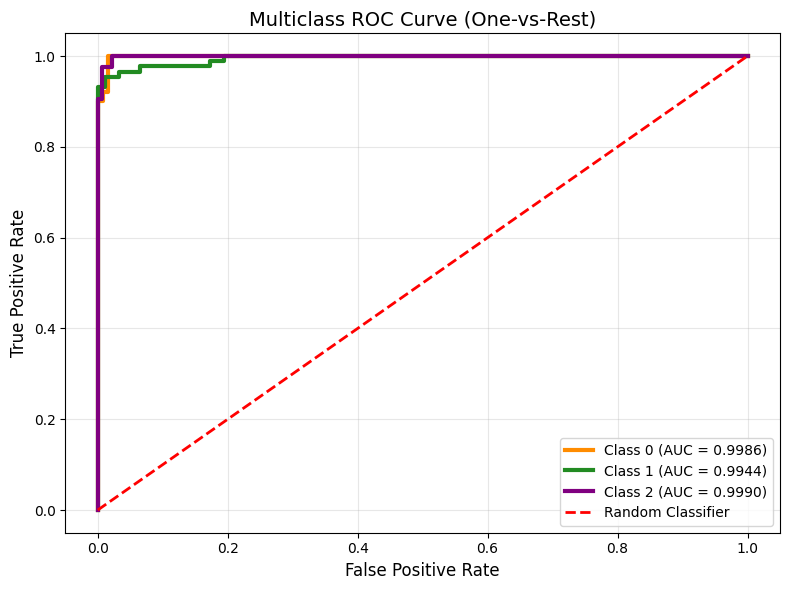


AUC Scores per Class:
Class 0 AUC: 0.9986
Class 1 AUC: 0.9944
Class 2 AUC: 0.9990

Macro-Average AUC: 0.9973


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from catboost import CatBoostClassifier

# ================= LOAD MODEL =================
MODEL_PATH = "outputs/catboost_optuna/catboost_best_model.cbm"

final_model = CatBoostClassifier()
final_model.load_model(MODEL_PATH)

# ================= ROC + AUC =================

# Get predicted probabilities
probs_test = final_model.predict_proba(X_test)

# Binarize test labels (One-vs-Rest)
classes = [0, 1, 2]
y_test_bin = label_binarize(y_test, classes=classes)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], probs_test[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

macro_auc = np.mean(list(roc_auc.values()))

# ================= IMPROVED PLOT =================

plt.figure(figsize=(8, 6))

# Clearly distinct colors
colors = ['darkorange', 'forestgreen', 'purple']

for i in range(len(classes)):
    plt.plot(
        fpr[i],
        tpr[i],
        color=colors[i],
        linewidth=3,
        label=f"Class {i} (AUC = {roc_auc[i]:.4f})"
    )

# Red baseline
plt.plot([0, 1], [0, 1],
         color='red',
         linestyle='--',
         linewidth=2,
         label='Random Classifier')

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("Multiclass ROC Curve (One-vs-Rest)", fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/catboost_optuna/roc_curve_multiclass.png", dpi=300)
plt.show()
# ================= PRINT RESULTS =================

print("\nAUC Scores per Class:")
for i in range(len(classes)):
    print(f"Class {i} AUC: {roc_auc[i]:.4f}")

print(f"\nMacro-Average AUC: {macro_auc:.4f}")

In [2]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier, Pool

# ================= CONFIG =================
DATA_PATH = "data/final_standardized_dataset(2).csv"
MODEL_PATH = "outputs/catboost_optuna/catboost_best_model.cbm"
OUT_DIR = "outputs/catboost_optuna/rag_explanations"

RANDOM_STATE = 42
TOP_K_FEATURES = 4

os.makedirs(OUT_DIR, exist_ok=True)
# =========================================


# ================= LOAD DATA =================
df = pd.read_csv(DATA_PATH)

df["risk_category"] = df["composite_risk_score"].apply(
    lambda s: 0 if s == 0 else (1 if s == 1 else 2)
)

exclude = [
    "patient_id",
    "composite_risk_score",
    "composite_risk_category",
    "risk_category"
]

features = [c for c in df.columns if c not in exclude]

X = df[features]
y = df["risk_category"]

cat_features = [i for i, c in enumerate(features) if X[c].dtype == "object"]


# =================  LOAD MODEL =================
model = CatBoostClassifier()
model.load_model(MODEL_PATH)


# =================  SPLIT DATA =================
_, X_test, _, y_test = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,
    random_state=RANDOM_STATE
)

probs = model.predict_proba(X_test)
preds = np.argmax(probs, axis=1)


# =================  SELECT ONE SAMPLE PER CLASS =================
selected_indices = {}

for cls in [0, 1, 2]:
    cls_idx = np.where(preds == cls)[0]
    if len(cls_idx) == 0:
        print(f"No prediction found for class {cls}")
        continue
    best = cls_idx[np.argmax(probs[cls_idx, cls])]
    selected_indices[cls] = best

print("\nSelected Samples:")
for cls, idx in selected_indices.items():
    print(f"Class {cls} -> Test index {idx} | Probability {probs[idx]}")


# =================  COMPUTE SHAP FOR SELECTED ONLY =================
selected_test_positions = list(selected_indices.values())
X_selected = X_test.iloc[selected_test_positions]

shap_pool = Pool(X_selected, cat_features=cat_features)

shap_values = model.get_feature_importance(
    shap_pool,
    type="ShapValues"
)

# Remove base value column
shap_values_clean = shap_values[:, :, :-1]


# =================  HELPER FUNCTIONS =================
def top_features(shap_vec, feature_names, k=4):
    idx = np.argsort(np.abs(shap_vec))[-k:][::-1]
    return [(feature_names[i], shap_vec[i]) for i in idx]


def generate_explanation(pred_class, prob, shap_vec):

    label_map = {0: "Low Risk", 1: "Moderate Risk", 2: "High Risk"}
    risk_name = label_map[pred_class]

    top_feats = top_features(shap_vec, features, TOP_K_FEATURES)

    explanation = []

    explanation.append("Cardiovascular Risk Assessment Report")
    explanation.append("-" * 50)
    explanation.append(f"Predicted Risk Category: {risk_name}")
    explanation.append(f"Prediction Confidence: {prob*100:.2f}%\n")

    explanation.append("Primary Contributing Biomarkers:")

    for rank, (f, v) in enumerate(top_feats, 1):
        direction = "positively" if v > 0 else "negatively"
        explanation.append(
            f"{rank}. {f} ({direction} contributed; SHAP impact = {v:.4f})"
        )

    explanation.append("\nModel Interpretation:")
    explanation.append(
        "The predicted risk classification is driven by the cumulative effect "
        "of the above biomarkers.\n Features with larger absolute SHAP values "
        "exert stronger influence on the final model decision."
    )

    explanation.append(
        "\nComparatively weaker feature contributions reduced the likelihood "
        "of alternative risk categories."
    )

    explanation.append(
        "\nClinical Note: This output represents a probabilistic estimate "
        "generated by a machine learning model.\n It is intended for decision-support "
        "purposes only and must not replace comprehensive clinical evaluation.\n "
        "All medical decisions should be made by a qualified healthcare professional."
    )

    return "\n".join(explanation)


# =================  GENERATE RAG-STYLE OUTPUT =================
print("\nRAG-STYLE EXPLANATIONS\n")

for i, (cls, test_idx) in enumerate(selected_indices.items()):

    explanation = generate_explanation(
        pred_class=cls,
        prob=probs[test_idx, cls],
        shap_vec=shap_values_clean[i, cls, :]
    )

    print("=" * 80)
    print(f"SAMPLE #{test_idx} | Predicted Class: {cls}")
    print("=" * 80)
    print(explanation)

    with open(f"{OUT_DIR}/sample_{test_idx}_class_{cls}.txt", "w") as f:
        f.write(explanation)

print("\n RAG-style explanations generated successfully for all available predicted classes.")


Selected Samples:
Class 0 -> Test index 52 | Probability [9.97348416e-01 2.51499620e-03 1.36587965e-04]
Class 1 -> Test index 103 | Probability [5.56723253e-04 9.98357493e-01 1.08578335e-03]
Class 2 -> Test index 67 | Probability [1.36182544e-04 6.20849211e-04 9.99242968e-01]

RAG-STYLE EXPLANATIONS

SAMPLE #52 | Predicted Class: 0
Cardiovascular Risk Assessment Report
--------------------------------------------------
Predicted Risk Category: Low Risk
Prediction Confidence: 99.73%

Primary Contributing Biomarkers:
1. c_reactive_protein (positively contributed; SHAP impact = 3.1412)
2. troponin_level (positively contributed; SHAP impact = 1.3180)
3. crp_hdl_ratio (positively contributed; SHAP impact = 0.5219)
4. troponin_crp_product (positively contributed; SHAP impact = 0.3885)

Model Interpretation:
The predicted risk classification is driven by the cumulative effect of the above biomarkers.
 Features with larger absolute SHAP values exert stronger influence on the final model decis